In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cngen = pd.read_csv("CN General Catalogues.csv")
cncpi = pd.read_csv("CN CPI index.csv")
cnspe = pd.read_csv("CN Specific Catalogues.csv")

cngen['Date'] = pd.to_datetime(cngen['Date'])
cncpi['Date'] = pd.to_datetime(cncpi['Date'])

In [3]:
genlunar = cngen[
    (cngen['Date'].dt.month.isin([1, 2])) &
    (cngen['Retail Sales (CNY 100M)'].isna())
]

genlunar = genlunar[['Date', 'Retail Sales (CNY 100M)', 'Retail Sales Tot Per Annu (CNY 100M)']]

genlunar['Retail Sales Tot Per Annu (CNY 100M)'] = genlunar['Retail Sales Tot Per Annu (CNY 100M)'].ffill()

days_in_month = genlunar['Date'].dt.days_in_month
jan1 = pd.to_datetime(genlunar['Date'].dt.year.astype(str) + '-01-01')
mar1 = pd.to_datetime(genlunar['Date'].dt.year.astype(str) + '-03-01')
days_janfeb = (mar1 - jan1).dt.days
genlunar['Retail Sales (CNY 100M)'] = (
    days_in_month / days_janfeb *
    genlunar['Retail Sales Tot Per Annu (CNY 100M)']
)

genlunar = genlunar[['Date', 'Retail Sales (CNY 100M)']]

In [4]:
cnadj = cngen.merge(genlunar, on = 'Date', how = 'left', suffixes=('', '_y'))
cnadj['Retail Sales (CNY 100M)'] = cnadj['Retail Sales (CNY 100M)'].combine_first(cnadj['Retail Sales (CNY 100M)_y'])
cnadj = cnadj.drop(columns=['Retail Sales (CNY 100M)_y'])

cnadj = cnadj[['Date', 'Retail Sales (CNY 100M)']].merge(cncpi, on = 'Date')

cnadj['Adjusted Retail Sales (CNY 100M)'] = cnadj[cnadj['Date'].dt.year>=1987]['Retail Sales (CNY 100M)'] / cnadj[cnadj['Date'].dt.year>=1987]['CPIIndex']

cnadj['CPIIndex'] = round(cnadj['CPIIndex'], 2)
cnadj['Adjusted Retail Sales (CNY 100M)'] = round(cnadj['Adjusted Retail Sales (CNY 100M)'], 2)

In [5]:
cnadj.head()

,Date,Retail Sales (CNY 100M),CPIIndex,Adjusted Retail Sales (CNY 100M)
0,2026-04-01,37247.00000,104.49,356.46
1,2026-03-01,41616.00000,104.18,399.46
2,2026-02-01,40851.00339,104.93,389.33
3,2026-01-01,45227.89661,103.98,434.98
4,2025-12-01,45135.90000,103.84,434.65


In [6]:
cncpi.head()

,Date,CPIIndex
0,2026-04-01,104.490100
1,2026-03-01,104.180723
2,2026-02-01,104.926158
3,2026-01-01,103.976333
4,2025-12-01,103.843452


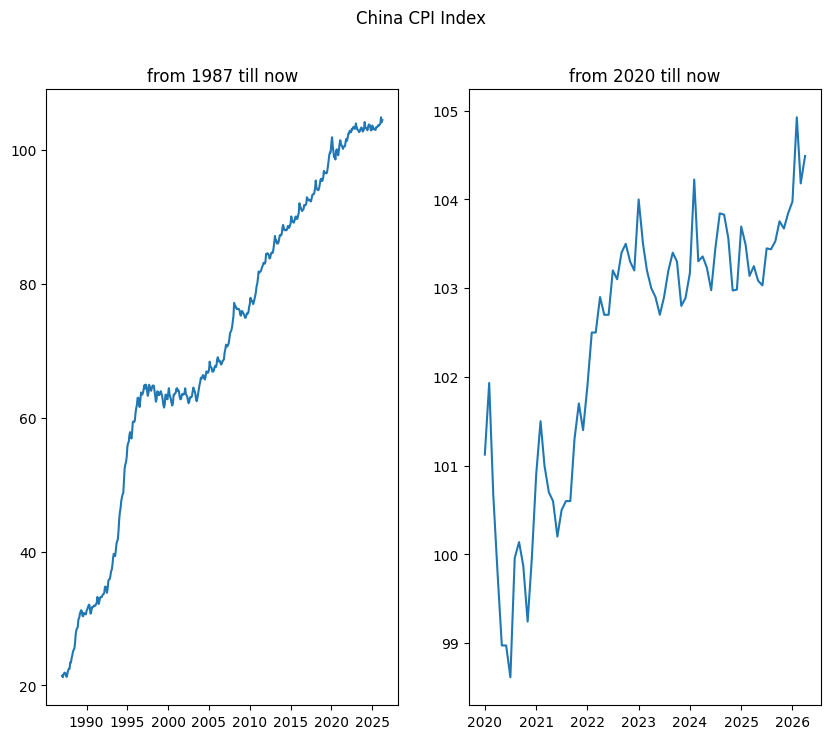

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10,8))

axs[0].plot(cncpi['Date'], cncpi['CPIIndex'])
axs[0].set_title("from 1987 till now")

cncpi_2020on = cncpi[cncpi['Date'].dt.year>=2020]
axs[1].plot(cncpi_2020on['Date'], cncpi_2020on['CPIIndex'])
axs[1].set_title("from 2020 till now")

plt.suptitle("China CPI Index")
plt.show()

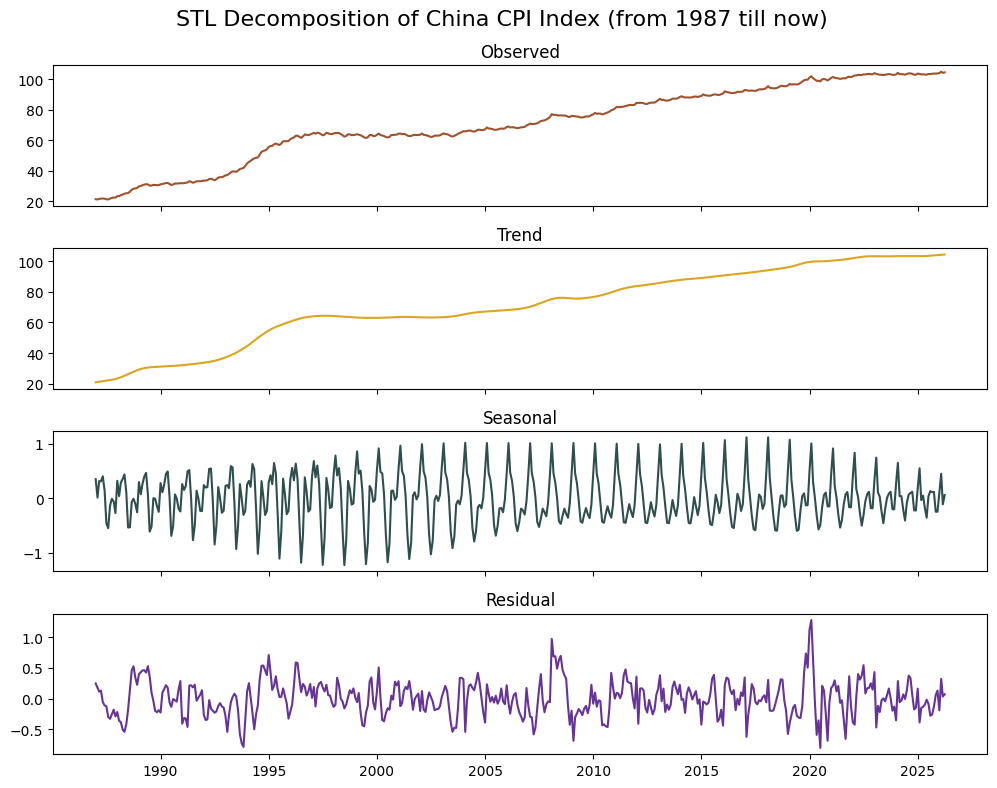

In [8]:
from statsmodels.tsa.seasonal import STL

cncpi_ts = cncpi.copy()
cncpi_ts.set_index('Date', inplace=True)
series = cncpi_ts['CPIIndex']

stl = STL(series, seasonal = 13)
result = stl.fit()

fig, axs = plt.subplots(4, 1, figsize=(10,8),sharex=True)

axs[0].plot(result.observed, color='sienna')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='goldenrod')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkslategrey')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='rebeccapurple')
axs[3].set_title('Residual')

plt.suptitle('STL Decomposition of China CPI Index (from 1987 till now)', fontsize=16)
plt.tight_layout()

plt.show()

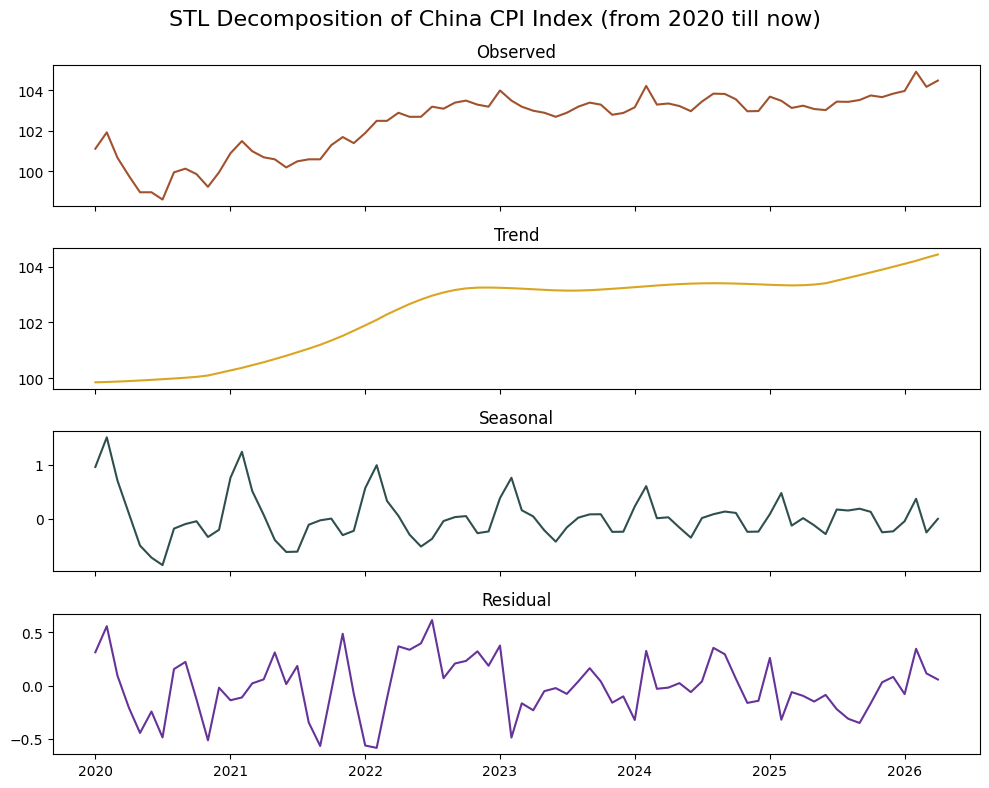

In [9]:
cncpi_2020on_ts = cncpi_2020on.copy()
cncpi_2020on_ts.set_index('Date', inplace=True)
series = cncpi_2020on_ts['CPIIndex']

stl = STL(series, seasonal = 13)
result = stl.fit()

fig, axs = plt.subplots(4, 1, figsize=(10,8),sharex=True)

axs[0].plot(result.observed, color='sienna')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='goldenrod')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkslategrey')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='rebeccapurple')
axs[3].set_title('Residual')

plt.suptitle('STL Decomposition of China CPI Index (from 2020 till now)', fontsize=16)
plt.tight_layout()

plt.show()

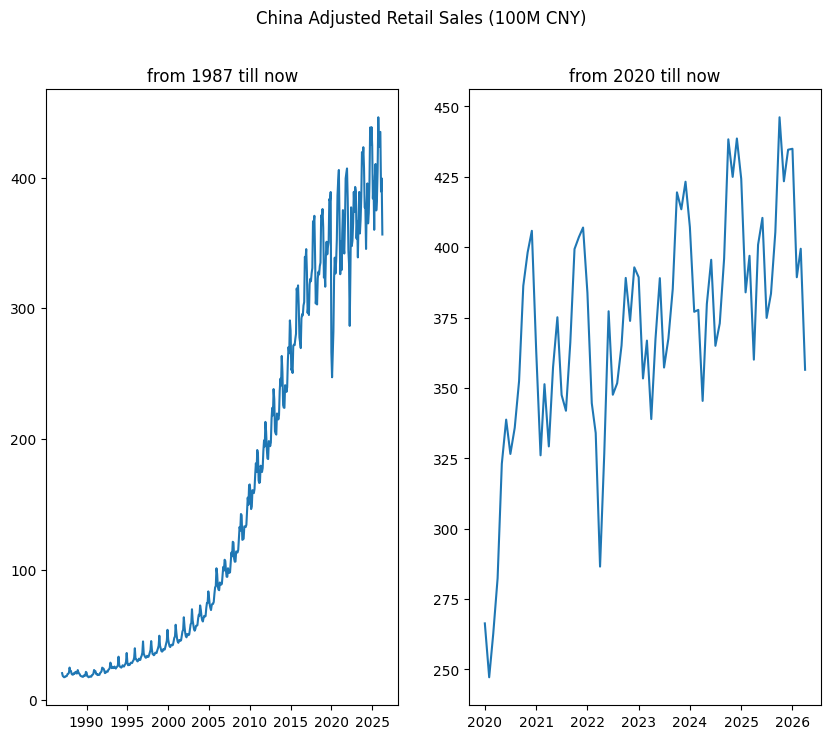

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10,8))

axs[0].plot(cnadj['Date'], cnadj['Adjusted Retail Sales (CNY 100M)'])
axs[0].set_title("from 1987 till now")

cnadj_2020on = cnadj[cncpi['Date'].dt.year>=2020]
axs[1].plot(cnadj_2020on['Date'], cnadj_2020on['Adjusted Retail Sales (CNY 100M)'])
axs[1].set_title("from 2020 till now")

plt.suptitle("China Adjusted Retail Sales (100M CNY)")
plt.show()

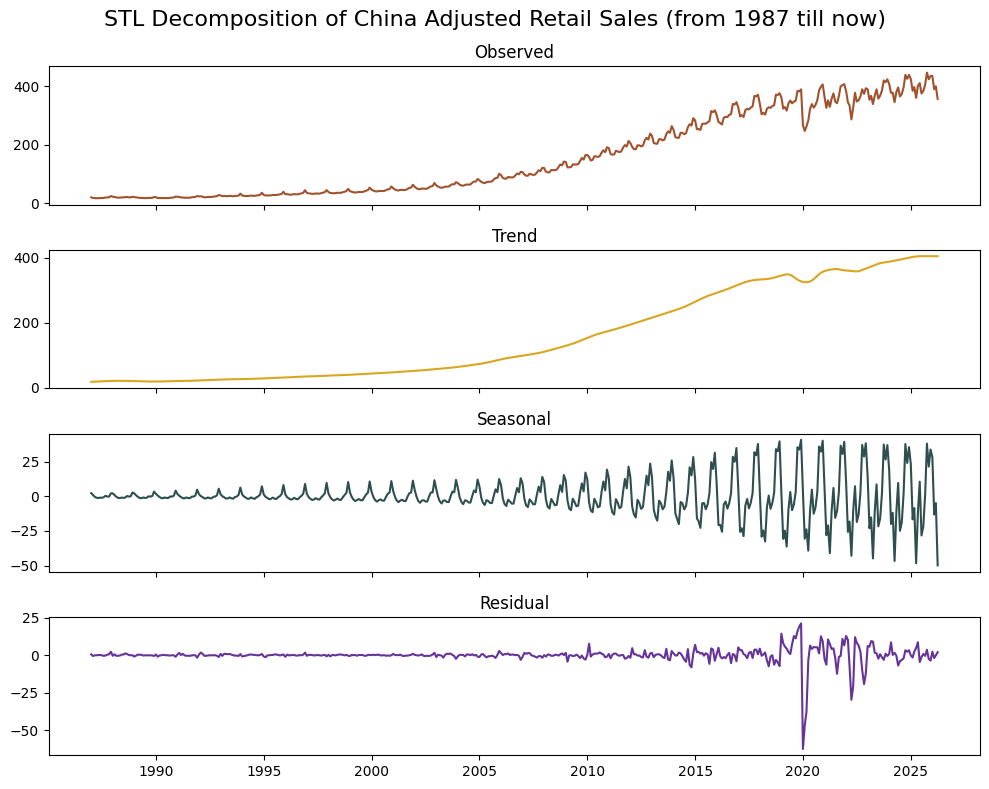

In [11]:
cnadj_ts = cnadj.copy()
cnadj_ts.set_index('Date', inplace=True)
series = cnadj_ts['Adjusted Retail Sales (CNY 100M)']

stl = STL(series, seasonal = 13)
result = stl.fit()

fig, axs = plt.subplots(4, 1, figsize=(10,8),sharex=True)

axs[0].plot(result.observed, color='sienna')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='goldenrod')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkslategrey')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='rebeccapurple')
axs[3].set_title('Residual')

plt.suptitle('STL Decomposition of China Adjusted Retail Sales (from 1987 till now)', fontsize=16)
plt.tight_layout()

plt.show()

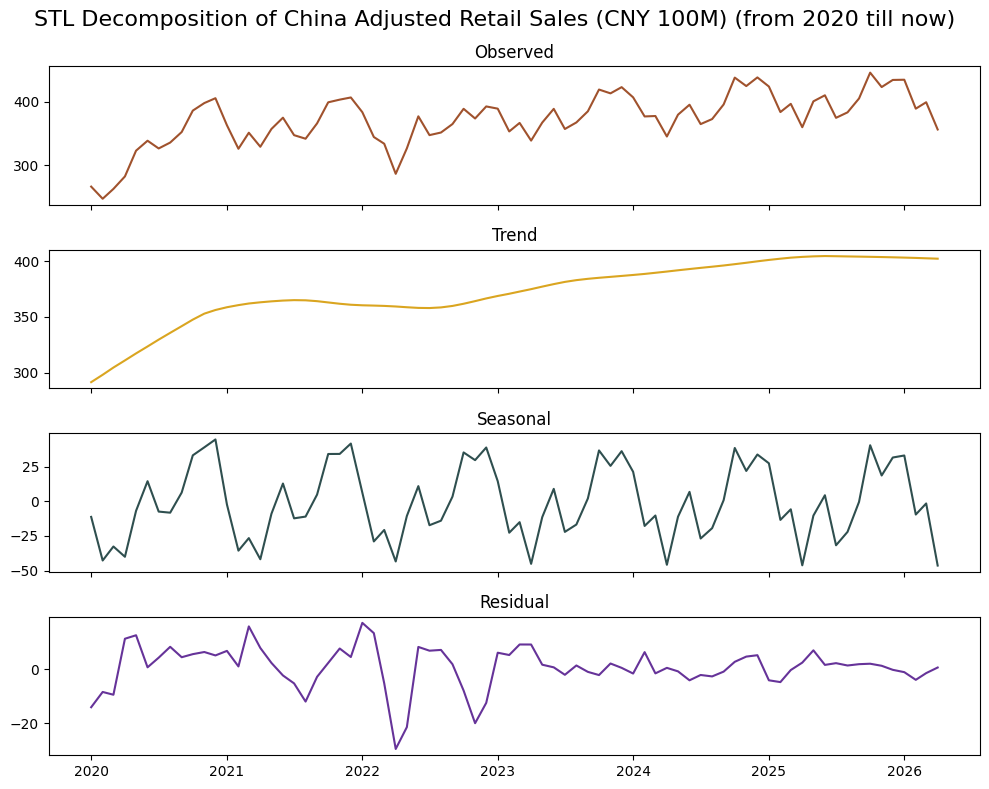

In [12]:
cnadj_2020on_ts = cnadj_2020on.copy()
cnadj_2020on_ts.set_index('Date', inplace=True)
series = cnadj_2020on_ts['Adjusted Retail Sales (CNY 100M)']

stl = STL(series, seasonal = 13)
result = stl.fit()

fig, axs = plt.subplots(4, 1, figsize=(10,8),sharex=True)

axs[0].plot(result.observed, color='sienna')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='goldenrod')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkslategrey')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='rebeccapurple')
axs[3].set_title('Residual')

plt.suptitle('STL Decomposition of China Adjusted Retail Sales (CNY 100M) (from 2020 till now)', fontsize=16)
plt.tight_layout()

plt.show()

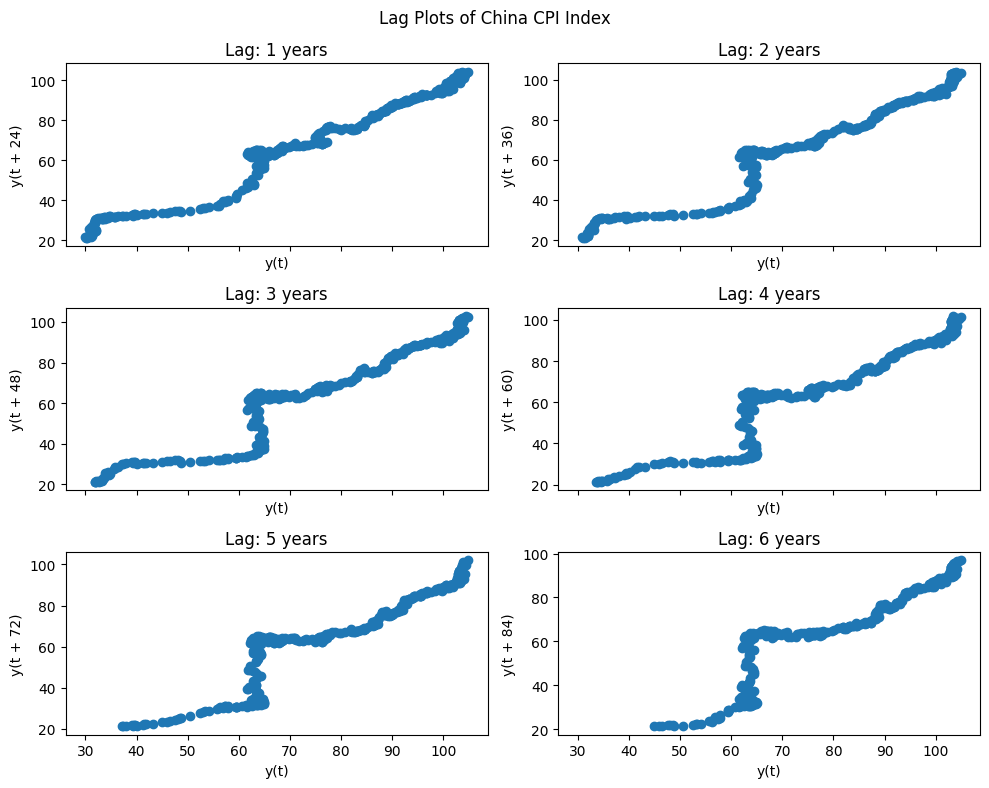

In [13]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cncpi_ts['CPIIndex'], lag = 12 * (i+2), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)} years")

plt.suptitle("Lag Plots of China CPI Index")
plt.tight_layout()
plt.show()

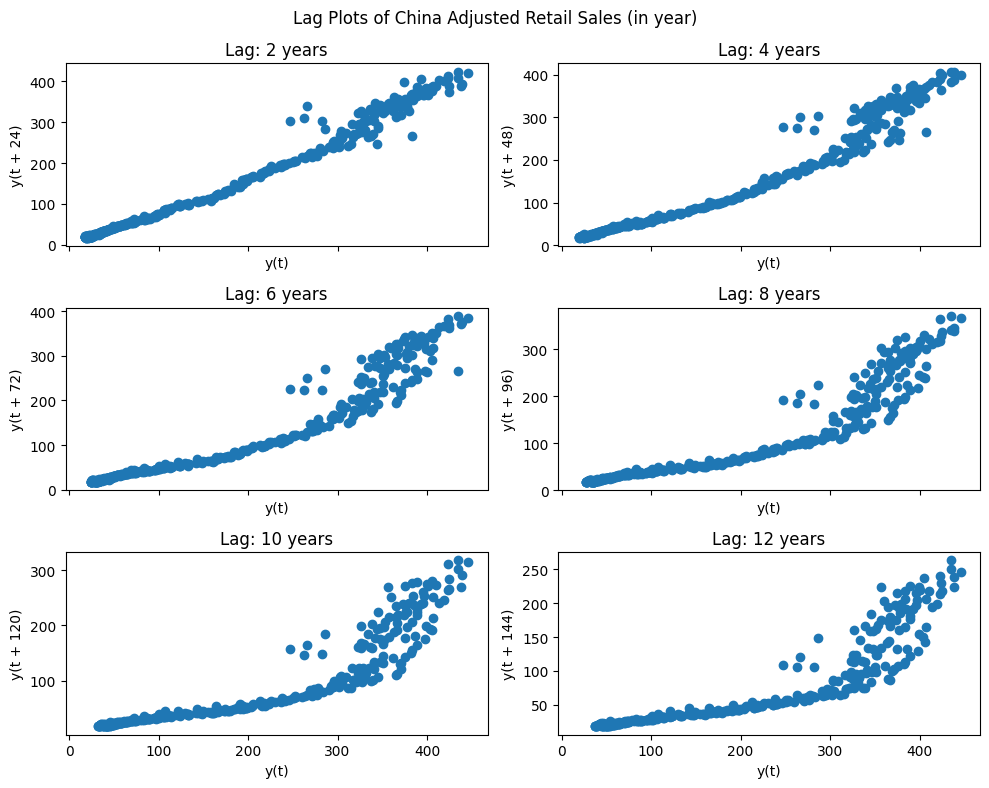

In [14]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cnadj_ts['Adjusted Retail Sales (CNY 100M)'], lag = 24 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} years")

plt.suptitle("Lag Plots of China Adjusted Retail Sales (in year)")
plt.tight_layout()
plt.show()

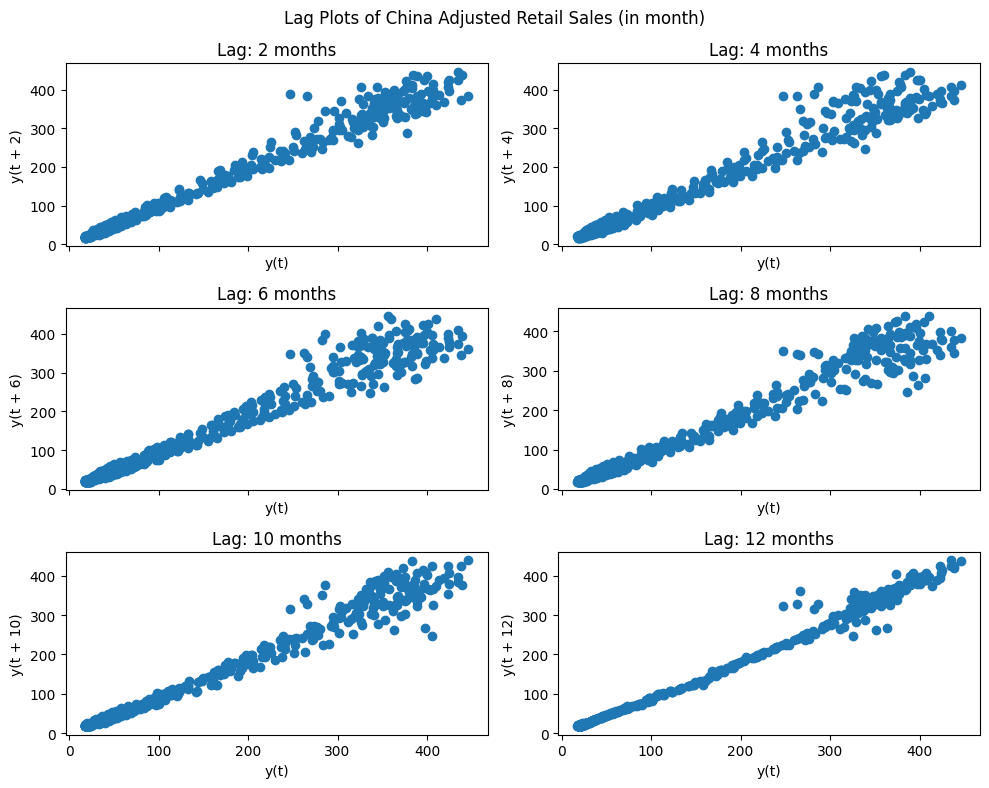

In [15]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cnadj_ts['Adjusted Retail Sales (CNY 100M)'], lag = 2 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} months")

plt.suptitle("Lag Plots of China Adjusted Retail Sales (in month)")
plt.tight_layout()
plt.show()